# LIBRARY

In [2]:
!pip install sktime

   ---------------------------------------- 0.0/36.3 MB ? eta -:--:--
   ---- ----------------------------------- 4.5/36.3 MB 24.4 MB/s eta 0:00:02
   ---------- ----------------------------- 9.4/36.3 MB 28.0 MB/s eta 0:00:01
   ------------ --------------------------- 11.5/36.3 MB 23.3 MB/s eta 0:00:02
   ------------- -------------------------- 12.6/36.3 MB 19.7 MB/s eta 0:00:02
   -------------- ------------------------- 13.1/36.3 MB 12.7 MB/s eta 0:00:02
   ----------------- ---------------------- 15.7/36.3 MB 13.4 MB/s eta 0:00:02
   -------------------- ------------------- 18.9/36.3 MB 13.1 MB/s eta 0:00:02
   ------------------------ --------------- 22.0/36.3 MB 13.3 MB/s eta 0:00:02
   -------------------------- ------------- 24.4/36.3 MB 13.1 MB/s eta 0:00:01
   ----------------------------- ---------- 27.0/36.3 MB 13.0 MB/s eta 0:00:01
   --------------------------------- ------ 30.4/36.3 MB 13.4 MB/s eta 0:00:01
   -------------------------------------- - 34.6/36.3 MB 13.9 M

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)
from sktime.transformations.series.adapt import TabularToSeriesAdaptor
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from sktime.classification.shapelet_based import ShapeletTransformClassifier
from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
from scikitplot.metrics import plot_roc

TypeError: C variable sklearn.utils._random.DEFAULT_SEED has wrong signature (expected __pyx_t_7sklearn_5utils_9_typedefs_uint32_t, got __pyx_t_7sklearn_5utils_9_typedefs_uint32_t const )

# DATAFRAMES

In [102]:
with gzip.open("../1.DATASET/CMI_timeseries_dataset.pkl.gz", "rb") as f:
	 CMI_timeseries_dataset = pickle.load(f)

In [103]:
# Check how many subjects/time series
print(f"Number of time series: {len(CMI_timeseries_dataset)}")

Number of time series: 4437


## FIRST ANALYSES

### COLUMNS

In [104]:
df = CMI_timeseries_dataset[0].copy()

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   X                    200 non-null    float32
 1   Y                    200 non-null    float32
 2   Z                    200 non-null    float32
 3   enmo                 200 non-null    float32
 4   anglez               200 non-null    float32
 5   non-wear_flag        200 non-null    float32
 6   light                200 non-null    float32
 7   battery_voltage      200 non-null    float32
 8   weekday              200 non-null    float64
 9   quarter              200 non-null    float64
 10  relative_date_PCIAT  200 non-null    float32
 11  id                   200 non-null    int64  
 12  sii_binary           200 non-null    int64  
dtypes: float32(9), float64(2), int64(2)
memory usage: 13.4 KB


### CLASS BALANCE

In [106]:
sii_distribution = [df['sii_binary'].iloc[0] for df in CMI_timeseries_dataset]
print(f"Class distribution: {sum(sii_distribution)} problematic, {len(sii_distribution)-sum(sii_distribution)} non-problematic")

Class distribution: 1480 problematic, 2957 non-problematic


### NULL VALUES

In [107]:
total_nulls = sum(df.isna().sum().sum() for df in CMI_timeseries_dataset)

if total_nulls == 0:
    print("No null values found in any DataFrame!")
else:
    print(f"Found {total_nulls} total null values")

No null values found in any DataFrame!


### UNIQUE VALUES

In [108]:
# attributes 
categorical_like = ['weekday', 'quarter', 'sii_binary', 'id', 'non-wear_flag']
continuous_like = ['X', 'Y', 'Z', 'enmo', 'anglez', 'light', 'battery_voltage', 'relative_date_PCIAT']

In [109]:
for col in categorical_like:
    all_values = sorted(set().union(*(df[col].unique() for df in CMI_timeseries_dataset)))
    print(f"\n{col}:\n   Unique values: {all_values}")


weekday:
   Unique values: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]

quarter:
   Unique values: [1.0, 2.0, 3.0, 4.0]

sii_binary:
   Unique values: [0, 1]

id:
   Unique values: [3, 25, 48, 51, 52, 63, 68, 82, 85, 90, 116, 118, 121, 129, 130, 132, 133, 134, 135, 140, 142, 150, 164, 167, 178, 179, 198, 200, 201, 206, 210, 214, 219, 220, 230, 231, 235, 239, 257, 270, 276, 277, 282, 284, 287, 300, 302, 310, 325, 339, 341, 347, 348, 354, 355, 367, 379, 380, 381, 382, 399, 407, 421, 428, 434, 459, 463, 465, 480, 503, 511, 514, 516, 520, 522, 523, 531, 537, 555, 558, 560, 566, 574, 575, 580, 599, 601, 606, 613, 633, 634, 642, 654, 657, 668, 670, 675, 681, 691, 692, 699, 706, 714, 717, 723, 732, 734, 735, 736, 739, 745, 749, 755, 764, 777, 783, 787, 789, 795, 797, 799, 828, 833, 835, 836, 839, 847, 851, 858, 861, 864, 881, 883, 884, 893, 894, 901, 910, 924, 929, 937, 941, 944, 956, 959, 969, 974, 975, 978, 981, 989, 996, 1008, 1011, 1014, 1017, 1024, 1027, 1028, 1035, 1044, 1050, 1054, 1056, 1069

In [110]:
for col in continuous_like:
    min_val, max_val = float('inf'), float('-inf')
    for df in CMI_timeseries_dataset:
        min_val, max_val = min(min_val, df[col].min()), max(max_val, df[col].max())
    print(f"\n{col}:\n   Range: [{min_val:.4f}, {max_val:.4f}]")


X:
   Range: [-8.0221, 1.3605]

Y:
   Range: [-2.0841, 1.5521]

Z:
   Range: [-1.0424, 8.0189]

enmo:
   Range: [0.0000, 7.0335]

anglez:
   Range: [-89.9032, 89.7458]

light:
   Range: [0.0000, 2594.6221]

battery_voltage:
   Range: [3099.0833, 6000.0000]

relative_date_PCIAT:
   Range: [-102.0000, 495.0000]


In [111]:
all_ids = [df['id'].iloc[0] for df in CMI_timeseries_dataset]
id_counts = Counter(all_ids)

In [112]:
print(f"{'-'*80}\nID FREQUENCY ANALYSIS\n{'-'*80}")
print(f"\nTotal DataFrames: {len(all_ids)}")
print(f"Unique IDs: {len(id_counts)}")
print(f"IDs appearing more than once: {sum(1 for c in id_counts.values() if c > 1)}")
print(f"IDs appearing only once: {sum(1 for c in id_counts.values() if c == 1)}")

--------------------------------------------------------------------------------
ID FREQUENCY ANALYSIS
--------------------------------------------------------------------------------

Total DataFrames: 4437
Unique IDs: 494
IDs appearing more than once: 253
IDs appearing only once: 241


In [113]:
# Filter for duplicates
duplicate_ids = {id_: count for id_, count in id_counts.items() if count > 1}

if duplicate_ids:
    # Extract only the items with the absolute highest and lowest repetitions
    max_id, max_count = max(duplicate_ids.items(), key=lambda x: x[1])
    min_id, min_count = min(duplicate_ids.items(), key=lambda x: x[1])
    
    print(f"\nIDs appear in multiple DataFrames:")
    print(f"   Maximum repetition -> ID {max_id}: appears {max_count} times")
    print(f"   Minimum repetition -> ID {min_id}: appears {min_count} times")



IDs appear in multiple DataFrames:
   Maximum repetition -> ID 2043: appears 36 times
   Minimum repetition -> ID 3186: appears 2 times


#### NON WEAR FLAG

In [114]:
groups = {'Always Wearing': [], 'Always Non-wear': [], 'Varying Pattern': []}
total = len(CMI_timeseries_dataset)

for df in CMI_timeseries_dataset:
    vals = df['non-wear_flag'].unique()
    target = df['sii_binary'].iloc[0]
    
    if len(vals) == 1:
        key = 'Always Wearing' if vals[0] == 0 else 'Always Non-wear'
    else:
        key = 'Varying Pattern'
    groups[key].append(target)

In [115]:
print(f"\nCategorization of {total} datasets:")
for name, cl in groups.items():
    print(f"  {name}: {len(cl)} ({len(cl)/total*100:.1f}%)")


Categorization of 4437 datasets:
  Always Wearing: 4258 (96.0%)
  Always Non-wear: 17 (0.4%)
  Varying Pattern: 162 (3.7%)


In [116]:
for name, cl in groups.items():
    if cl:
        prob = sum(cl)
        print(f"\nClass distribution for {name}:")
        print(f"  Problematic (sii_binary=1): {prob} ({prob/len(cl)*100:.1f}%)")
        print(f"  Non-problematic (sii_binary=0): {len(cl)-prob} ({(len(cl)-prob)/len(cl)*100:.1f}%)")


Class distribution for Always Wearing:
  Problematic (sii_binary=1): 1403 (32.9%)
  Non-problematic (sii_binary=0): 2855 (67.1%)

Class distribution for Always Non-wear:
  Problematic (sii_binary=1): 9 (52.9%)
  Non-problematic (sii_binary=0): 8 (47.1%)

Class distribution for Varying Pattern:
  Problematic (sii_binary=1): 68 (42.0%)
  Non-problematic (sii_binary=0): 94 (58.0%)


### STATISTICS

In [117]:
global_df = pd.concat(CMI_timeseries_dataset, ignore_index=True)
percentiles = [.01, .05, .10, .25, .50, .75, .90, .95, .99]
global_stats = global_df.describe(percentiles=percentiles)

print(f"GLOBAL DESCRIPTIVE STATISTICS (All Subjects Combined):\n")
print(global_stats)

GLOBAL DESCRIPTIVE STATISTICS (All Subjects Combined):

                   X              Y              Z           enmo  \
count  887400.000000  887400.000000  887400.000000  887400.000000   
mean       -0.092578       0.003362      -0.091223       0.056764   
std         0.538658       0.358403       0.423635       0.084195   
min        -8.022103      -2.084078      -1.042407       0.000000   
1%         -0.928149      -0.828171      -0.976485       0.000000   
5%         -0.809811      -0.601036      -0.785295       0.001043   
10%        -0.728483      -0.461969      -0.630218       0.004837   
25%        -0.571236      -0.230633      -0.364926       0.014106   
50%        -0.202865       0.002289      -0.114865       0.030716   
75%         0.435963       0.236372       0.152181       0.066491   
90%         0.658907       0.469673       0.490473       0.128631   
95%         0.759112       0.608892       0.695505       0.192282   
99%         0.913711       0.844721       0.983

In [118]:
global_df.shape

(887400, 13)

In [119]:
global_df[global_df['non-wear_flag']==0]

,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,weekday,quarter,relative_date_PCIAT,id,sii_binary
0,-0.696639,-0.058477,-0.086717,0.051424,-6.090168,0.0,21.794674,4023.000000,4.0,4.0,253.0,2265,0
1,-0.479150,0.218840,-0.289497,0.062909,-19.893288,0.0,20.835835,4023.000000,4.0,4.0,253.0,2265,0
2,-0.440287,-0.171177,-0.326227,0.121546,-23.043303,0.0,6.294650,4023.000000,4.0,4.0,253.0,2265,0
3,-0.559035,-0.293204,-0.145227,0.084953,-9.694811,0.0,0.462963,4022.616699,4.0,4.0,253.0,2265,0
4,-0.531364,-0.210126,-0.086370,0.074157,-6.412807,0.0,4.058062,4020.583252,4.0,4.0,253.0,2265,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
887395,0.109243,0.581290,0.320458,0.056306,20.626949,0.0,13.580427,3689.000000,5.0,2.0,36.0,580,1
887396,-0.524706,0.227063,0.363919,0.081404,23.889679,0.0,13.534304,3689.000000,5.0,2.0,36.0,580,1
887397,-0.451121,-0.028637,0.405358,0.034749,25.322130,0.0,13.487847,3689.000000,5.0,2.0,36.0,580,1
887398,0.548647,0.177419,-0.791097,0.020374,-53.796261,0.0,13.441450,3689.000000,5.0,2.0,36.0,580,1


### INDIVIDUAL GRAPHICS

In [120]:
import matplotlib.pyplot as plt


def plot_subject_dashboard(dataset, target_id=None, dataset_idx=None):
    matched_dfs = []  # Stores tuples of (index, dataframe)

    # 1. Option A: Fetch by direct index position
    if dataset_idx is not None:
        if 0 <= dataset_idx < len(dataset):
            matched_dfs.append((dataset_idx, dataset[dataset_idx]))
        else:
            print(f"Dataset index {dataset_idx} is out of bounds.")
            return

    # 2. Option B: Collect ALL matching dataframes for this User ID
    elif target_id is not None:
        matched_dfs = [
            (idx, df)
            for idx, df in enumerate(dataset)
            if str(df["id"].iloc[0]) == str(target_id)
        ]

    # Guard clause if no datasets were found
    if not matched_dfs:
        print(f"No matching datasets found for the given criteria.")
        return

    # 3. Dynamic Side-by-Side Plotting Configuration
    n_matches = len(matched_dfs)
    # Get the columns from the first matched dataframe to calculate rows
    numeric_cols = matched_dfs[0][1].select_dtypes(include="number").columns
    n_rows = len(numeric_cols)

    # Create a dynamic grid: Rows = Features, Columns = Each appearance of the user
    fig, axes = plt.subplots(
        n_rows,
        n_matches,
        figsize=(5 * n_matches, 2 * n_rows),
        sharex=False,  # Can set to True now since all share the same 0-200 window
        squeeze=False,
    )

    # 4. Populate the subplots dynamically
    for col_idx, (ds_idx, df) in enumerate(matched_dfs):
        subj_id = df["id"].iloc[0]
        plot_df = df.select_dtypes(include="number")

        for row_idx, col_name in enumerate(numeric_cols):
            ax = axes[row_idx, col_idx]  # Fixed the walrus operator typo here

            # Plot the specific feature column sequence
            ax.plot(df[col_name].values, alpha=0.8)

            # ── CRITICAL ADDITION: FORCE X-AXIS SCALE 0 TO 200 ────────────────
            ax.set_xlim(0, 200)

            # Add titles only to the top row to keep layout clean
            if row_idx == 0:
                ax.set_title(
                    f"Appearance #{col_idx+1}\n(Dataset #{ds_idx})",
                    weight="bold",
                )

            # Add labels to the left-most plots
            if col_idx == 0:
                ax.set_ylabel(col_name, weight="bold")

            ax.grid(True, alpha=0.3)

    plt.suptitle(
        f"Side-by-Side Metrics Matrix for Subject {target_id if target_id else subj_id} ({n_matches} total appearances)",
        fontsize=14,
        weight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

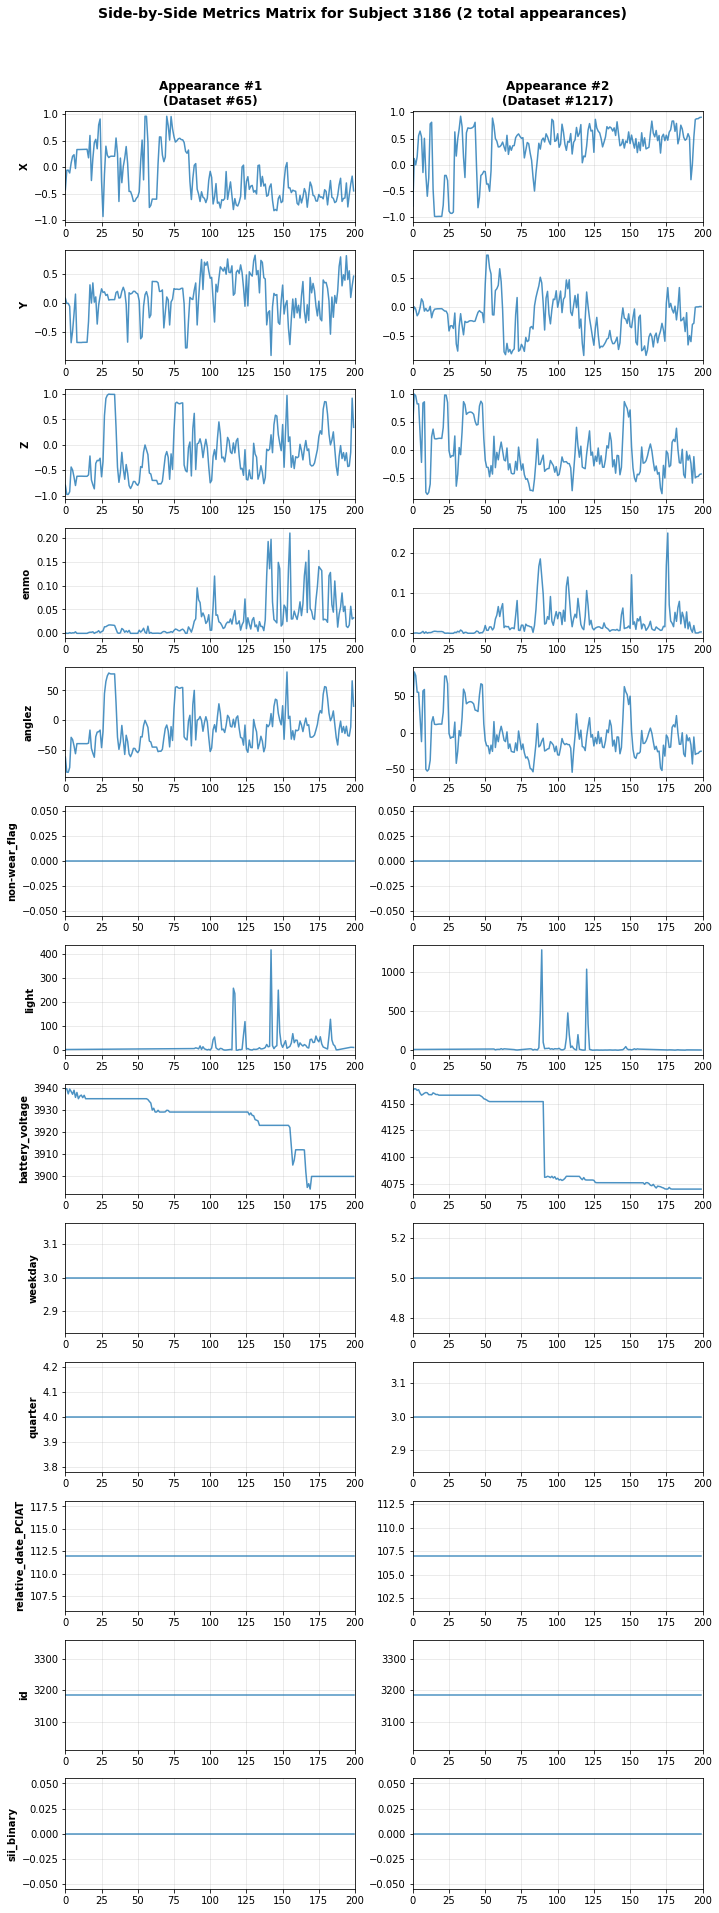

In [121]:
plot_subject_dashboard(CMI_timeseries_dataset, target_id="3186", dataset_idx=None)

# SELECTION


In [122]:
import numpy as np
kept_data, removed_data = [], []

for df in CMI_timeseries_dataset:
    if df["non-wear_flag"].mean() <= 0.5:
        kept_data.append(df)
    else:
        removed_data.append(df)

# Output summary metrics
print(f"Original: {len(CMI_timeseries_dataset)}")
print(f"Kept: {len(kept_data)} (always wear + mostly wear)")
print(f"Removed: {len(removed_data)} (mostly non-wear)")



Original: 4437
Kept: 4307 (always wear + mostly wear)
Removed: 130 (mostly non-wear)


In [123]:
# Compute distributions directly from the lists
orig_prob = sum(df["sii_binary"].iloc[0] for df in CMI_timeseries_dataset)
filt_prob = sum(df["sii_binary"].iloc[0] for df in kept_data)

print(f"\nProblematic: {orig_prob} → {filt_prob}")
print(
    f"Non-problematic: {len(CMI_timeseries_dataset)-orig_prob} → {len(kept_data)-filt_prob}"
)


Problematic: 1480 → 1420
Non-problematic: 2957 → 2887


In [124]:
analysis = []
for i, df in enumerate(CMI_timeseries_dataset):
    vals = df["non-wear_flag"].values
    mean_val = vals.mean()  # Fraction of time spent in non-wear state (1)

    # Only process subjects with actual varying patterns (contains both 0 and 1)
    if 0 < mean_val < 1:
        pct_wear = (1 - mean_val) * 100
        analysis.append(
            {
                "dataframe_idx": i,
                "id": df["id"].iloc[0],
                "sii_binary": df["sii_binary"].iloc[0],
                "class": (
                    "Problematic"
                    if df["sii_binary"].iloc[0] == 1
                    else "Non-problematic"
                ),
                "percent_wearing": pct_wear,
                "percent_non_wear": mean_val * 100,
                "transitions": np.sum(np.diff(vals) != 0),
                "dominant_state": 0 if pct_wear > 50 else 1,
                "dominant_label": (
                    "Mostly Wearing" if pct_wear > 50 else "Mostly Non-wear"
                ),
            }
        )

varying_df = pd.DataFrame(analysis)
total = len(varying_df)


In [125]:
print(f"Found {total} varying wear subjects\n\nSUMMARY\n")
# 1. High-level state distributions
m_wear = (varying_df["dominant_state"] == 0).sum()
print(f"Mostly Wearing: {m_wear} subjects ({m_wear/total*100:.1f}%)")
print(
    f"Mostly Non-wear: {total - m_wear} subjects ({(total - m_wear)/total*100:.1f}%)"
)

Found 162 varying wear subjects

SUMMARY

Mostly Wearing: 49 subjects (30.2%)
Mostly Non-wear: 113 subjects (69.8%)


In [126]:
print(
    f"\nMOSTLY NON-WEAR (>50%):\n{varying_df[varying_df['dominant_state'] == 1][['id', 'class', 'percent_non_wear', 'transitions']].to_string(index=False)}"
)
print(
    f"\nMOSTLY WEARING (>50%):\n{varying_df[varying_df['dominant_state'] == 0][['id', 'class', 'percent_wearing', 'transitions']].head(20).to_string(index=False)}"
)


MOSTLY NON-WEAR (>50%):
  id           class  percent_non_wear  transitions
  51     Problematic         95.499998           15
3847     Problematic         81.999999           15
1411 Non-problematic         73.745835           20
 881 Non-problematic         91.084725           14
 463     Problematic         96.669447           16
3520 Non-problematic         64.254165           27
1099 Non-problematic         92.500001           15
2251 Non-problematic         61.000001           32
2848 Non-problematic         84.254164            4
 198 Non-problematic         65.499997           31
2953 Non-problematic         98.500001            7
 789 Non-problematic         86.500001           36
1855     Problematic         88.000000           23
 606 Non-problematic         75.999999           32
 599 Non-problematic         78.254163           12
2779 Non-problematic         96.754164           11
 132 Non-problematic         71.499997           15
1657 Non-problematic         94.000000 

In [127]:
always_wear, mostly_wear = [], []
always_non_wear, mostly_non_wear = [], []
total = len(CMI_timeseries_dataset)

for df in CMI_timeseries_dataset:
    vals = df["non-wear_flag"].values
    non_wear_mean = vals.mean()  # Fraction of time spent not wearing device
    
    # Check if constant (either 0.0 or 1.0 exactly)
    is_constant = non_wear_mean == 0 or non_wear_mean == 1

    if non_wear_mean <= 0.5:  # Wear time >= 50% (KEEP)
        always_wear.append(df) if is_constant else mostly_wear.append(df)
    else:                     # Wear time < 50%  (DROP)
        always_non_wear.append(df) if is_constant else mostly_non_wear.append(df)

# Construct final subset and tracking aggregates
CMI_timeseries_filtered = always_wear + mostly_wear
n_keep, n_drop = len(CMI_timeseries_filtered), total - len(CMI_timeseries_filtered)

print(f"Dataset Composition (Total: {total})")
print(f"KEEP: Always wear: {len(always_wear)} | Mostly wear: {len(mostly_wear)} | Total: {n_keep} ({n_keep/total*100:.1f}%)")
print(f"DROP: Always non-wear: {len(always_non_wear)} | Mostly non-wear: {len(mostly_non_wear)} | Total: {n_drop} ({n_drop/total*100:.1f}%)")
print(f"Created filtered dataset with {n_keep} time series")

# Vectorized Class Distribution Checks
orig_prob = sum(df["sii_binary"].iloc[0] for df in CMI_timeseries_dataset)
filt_prob = sum(df["sii_binary"].iloc[0] for df in CMI_timeseries_filtered)
print(f"Class Distribution (Problematic):\n  Original: {orig_prob} ({orig_prob/total*100:.1f}%)\n  Filtered: {filt_prob} ({filt_prob/n_keep*100:.1f}%)")

# Compressed Storage dump
print(f" NEW DATA: CMI_timeseries_filtered")

Dataset Composition (Total: 4437)
KEEP: Always wear: 4258 | Mostly wear: 49 | Total: 4307 (97.1%)
DROP: Always non-wear: 17 | Mostly non-wear: 113 | Total: 130 (2.9%)
Created filtered dataset with 4307 time series
Class Distribution (Problematic):
  Original: 1480 (33.4%)
  Filtered: 1420 (33.0%)
 NEW DATA: CMI_timeseries_filtered


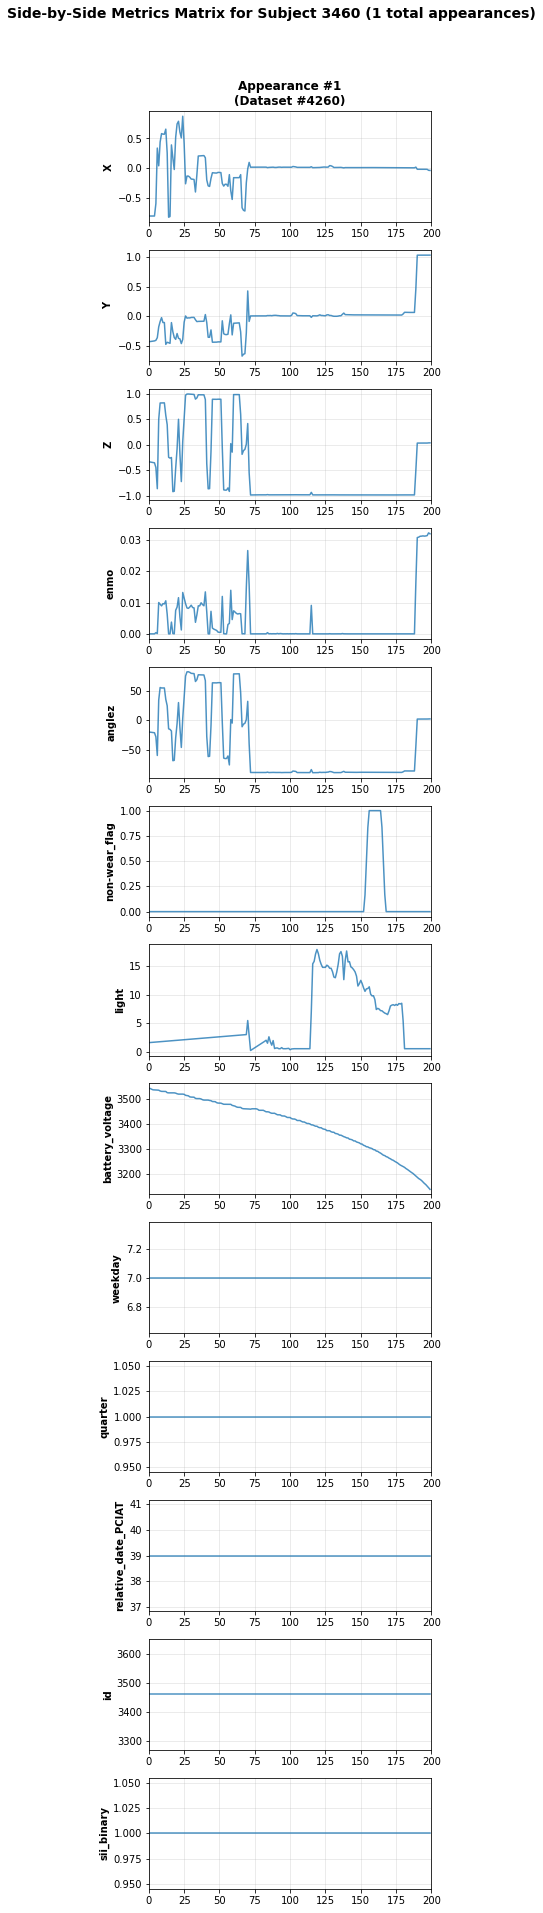

In [128]:
plot_subject_dashboard(CMI_timeseries_filtered, target_id="3460", dataset_idx=None)

## TRANSFORM NULL VALUES 

In [129]:
# Automatically detect available sensor columns (excluding metadata)
exclude = ["id", "sii_binary", "weekday", "quarter", "non-wear_flag"]
sensor_cols = [col for col in CMI_timeseries_filtered[0].columns if col not in exclude]

# Inline conversion using list comprehension and DataFrame assignment method
for df in CMI_timeseries_filtered:
    df.loc[df["non-wear_flag"] == 1, sensor_cols] = np.nan

print(f"Converted non-wear periods to NaN across {len(CMI_timeseries_filtered)} time series.")

Converted non-wear periods to NaN across 4307 time series.


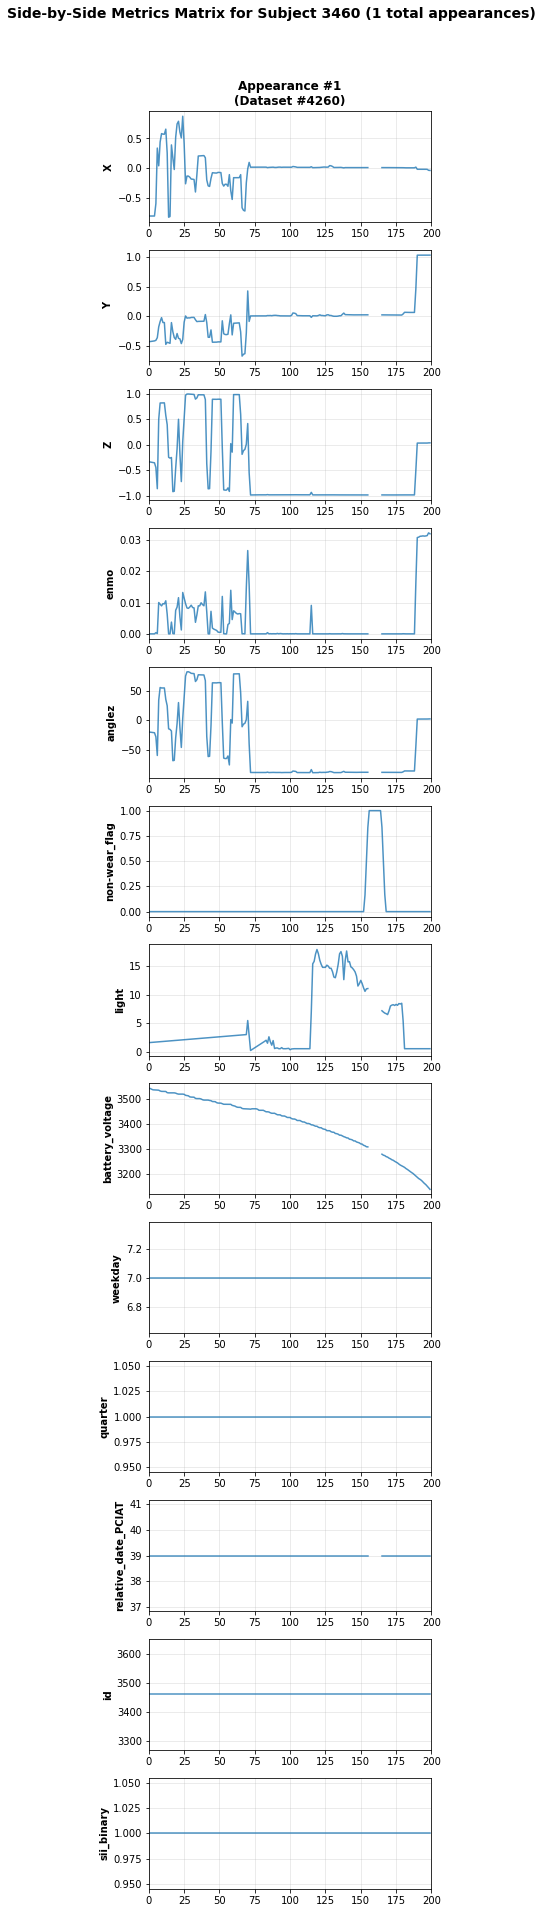

In [130]:
plot_subject_dashboard(CMI_timeseries_filtered, target_id="3460", dataset_idx=None)

## INTERPOLATION

In [131]:

for df in CMI_timeseries_filtered:
    df[sensor_cols] = df[sensor_cols].interpolate(
        method="linear", limit_direction="both"
    )

print(
    f"Successfully interpolated missing values across {len(CMI_timeseries_filtered)} time series."
)



Successfully interpolated missing values across 4307 time series.


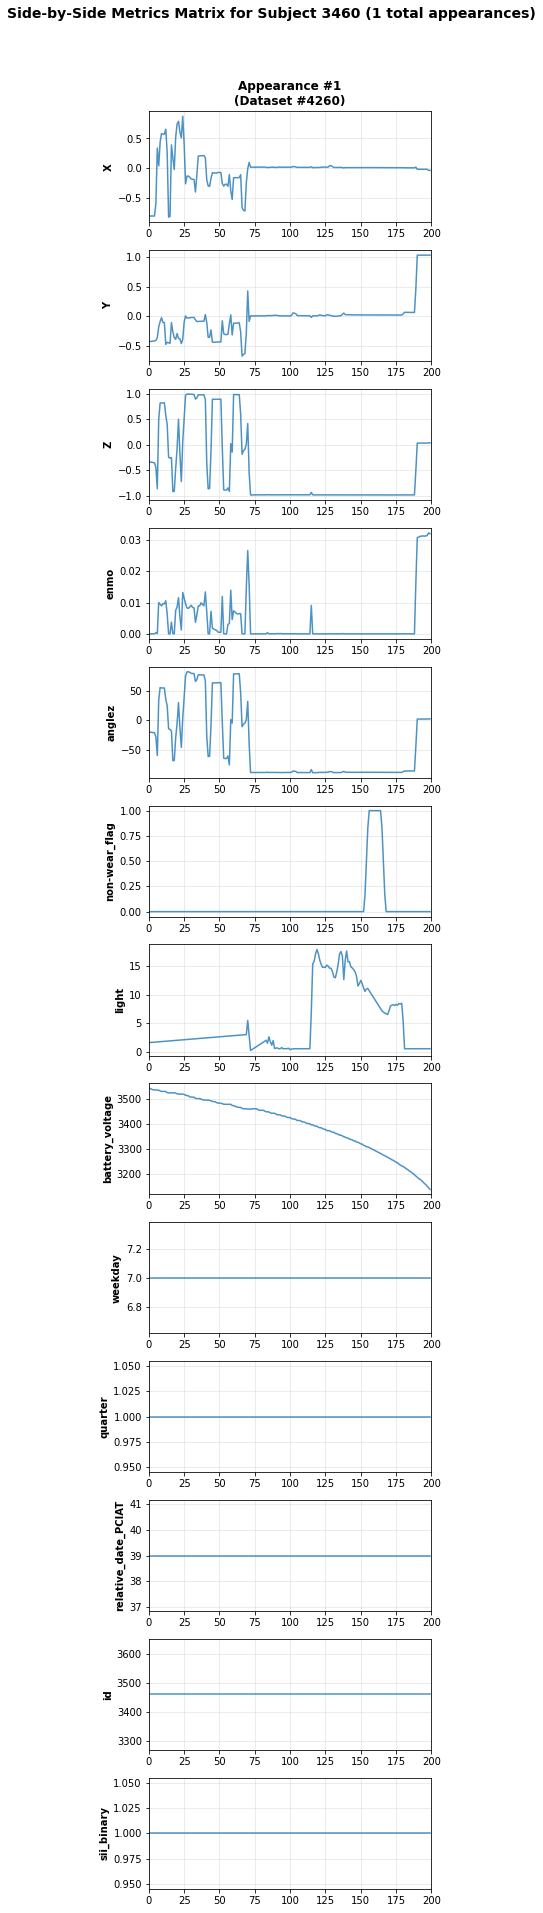

In [132]:
plot_subject_dashboard(CMI_timeseries_filtered, target_id="3460", dataset_idx=None)

In [133]:
# Save
with gzip.open("../1.DATASET/CMI_timeseries_filtered.pkl.gz", "wb") as f:
    pickle.dump(CMI_timeseries_filtered, f)

print(f"Saved: CMI_timeseries_filtered.pkl.gz")

Saved: CMI_timeseries_filtered.pkl.gz


# NORMALIZATION

## LOAD THE INTERPOLATED/CLEAN DATA

In [134]:
# Check how many subjects/time series
with gzip.open("../1.DATASET/CMI_timeseries_filtered.pkl.gz", "rb") as f:
	
	 data = pickle.load(f)
print(f"Number of time series: {len(data)}")
total_subjects = len(data) 

Number of time series: 4307


In [135]:
signals = [
    "enmo",
    "anglez",
    "light",
    "X",
    "Y",
    "Z",
    "battery_voltage"
]
results = {}

TREND_ALLOWED_SIGNALS = ["battery_voltage","light" ]
LOG_ALLOWED_SIGNALS = ["enmo","anglez","light", "X", "Y", "Z"]
SEASONAL_ALLOWED_SIGNALS = ["enmo", "anglez", "light", "X", "Y", "Z", "battery_voltage"]

## PARAMETERS

In [136]:
N_PERMUTATIONS = 100  # The number of times the function shuffles your time series to build a baseline profile of random chance noise.
SEASONALITY_LAG = 48  # 24-hour cycle - 48 steps equal exactly 24 hours
HETERO_WINDOW = 48  # 24-hour window for variance

# Much stricter alphas to stop tests from flagging minor variations
ADF_ALPHA = 0.001  # Extemely strict trend detection  To confirm a trend exists, the $p$-value from the ADF test must be very high
KPSS_ALPHA = 0.01 #  and the $p$-value from the KPSS test must be lower than 0.01. 
LEVENE_ALPHA = 0.01  # Low alpha prevents over-applying log1p # low value like 0.01 means the variance difference must be massive before the code triggers log1p.


## FUNCTIONS

In [137]:
def get_local_acf_threshold(ts, lag, n_perm=N_PERMUTATIONS):
    n_elements = len(ts)
    if n_elements <= lag:
        return 0.0
    rng = np.random.default_rng()
    shuffled_indices = [rng.permutation(n_elements) for _ in range(n_perm)]
    surrogate_corrs = [
        abs(np.corrcoef(ts[idxs][:-lag], ts[idxs][lag:])[0, 1])
        for idxs in shuffled_indices
    ]
    clean_corrs = [c for c in surrogate_corrs if not np.isnan(c)]
    # Use 99th percentile instead of 95th to set a much higher bar for seasonality
    return np.percentile(clean_corrs, 99) if clean_corrs else 0.0

In [138]:
def safe_hampel_filter(y, window_size=5, n_sigmas=3):
    n = len(y)
    y_clean = y.copy()
    # Constant scaling factor for an approximate normal distribution
    k = 1.4826 
    
    for i in range(window_size, n - window_size):
        # Extract the moving window around the current point
        window = y[i - window_size : i + window_size + 1]
        median = np.median(window)
        mad = np.median(np.abs(window - median))
        
        # Noise tolerance threshold
        threshold = n_sigmas * k * mad
        
        if np.abs(y[i] - median) > threshold and mad > 1e-6:
            y_clean[i] = median # Replace the spike with the local median
            
    return y_clean

## DIAGNOSTIC PASS PER ID

In [139]:
TARGET_ID = "198" 
target_df = None
for df in data:
    if str(df["id"].iloc[0]) == str(TARGET_ID):
        target_df = df.copy()
        break

In [140]:
target_df

,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,weekday,quarter,relative_date_PCIAT,id,sii_binary
0,0.889046,0.348297,0.216287,0.000589,12.742727,0.0,1.400928,3642.000000,7.0,3.0,124.0,198,0
1,0.047943,0.330606,-0.024057,0.001107,-1.703475,0.0,1.424125,3642.000000,7.0,3.0,124.0,198,0
2,-0.803870,0.277308,-0.516304,0.000105,-31.252678,0.0,1.447323,3642.000000,7.0,3.0,124.0,198,0
3,-0.864502,0.236196,-0.064404,0.005449,-3.909372,0.0,1.470520,3642.000000,7.0,3.0,124.0,198,0
4,-0.848018,-0.287042,-0.169243,0.002178,-10.122394,0.0,1.493717,3640.725098,7.0,3.0,124.0,198,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-0.657261,0.730043,-0.144113,0.019245,-8.288386,0.0,27.201530,3483.000000,7.0,3.0,124.0,198,0
196,-0.664854,0.230061,0.090398,0.032303,5.844979,0.0,34.854591,3481.833252,7.0,3.0,124.0,198,0
197,-0.505768,0.639126,-0.249226,0.028566,-17.438173,0.0,12.820533,3478.508301,7.0,3.0,124.0,198,0
198,-0.519830,0.703613,0.072979,0.021592,4.198713,0.0,9.066498,3478.000000,7.0,3.0,124.0,198,0


### old code

In [ ]:
CMI_timeseries_personalized = []
if target_df is None:
    print(f"Could not find a dataset with ID: {TARGET_ID}")
else:
    print(f"{'='*70}\nANALYZING AND TRANSFORMING ID: {TARGET_ID}\n{'='*70}")

    local_transforms_applied = {"log1p": 0, "detrend": 0, "deseasonal": 0}

    for signal in signals:
        if signal not in target_df.columns:
            continue

        # 1. Grab the fully interpolated continuous signal array
        y = target_df[signal].values.copy()
        n_samples = len(y)

        # 2. SIMPLE LENGTH & FLATNESS GUARD - validate the signal
        if n_samples < SEASONALITY_LAG + 10 or np.ptp(y) == 0:
            continue
        if np.std(y) < 0.0001:
            continue

        # ── STEP 0: HAMPEL NOISE CLEANING (BEFORE DIAGNOSTICS) ────────────────
        # Apply Hampel to physical/environmental sensors prone to sudden impact spikes
        if signal in ["X", "Y", "Z", "enmo", "anglez", "light"]:
            y_filtered = safe_hampel_filter(y, window_size=5, n_sigmas=3)
            
            # If the Hampel filter actually modified any noisy data points, log it
            if not np.array_equal(y, y_filtered):
                y = y_filtered # Keep the cleaned signal array

        # ── STEP 1: INDIVIDUAL DIAGNOSIS ON THE ENTIRE SIGNAL ────────────────
        
        # Heteroscedasticity Test
        need_log1p = False
        if signal in LOG_ALLOWED_SIGNALS:
            n_blocks = n_samples // HETERO_WINDOW
            if n_blocks >= 3:
                # FIX: We test the ABSOLUTE values for variance shifts.
                # This prevents negative offsets from breaking the mathematical ratio.
                y_abs = np.abs(y)
                blocks = np.reshape(y_abs[: n_blocks * HETERO_WINDOW], (n_blocks, HETERO_WINDOW))
                _, levene_p = levene(*blocks, center="median")
                need_log1p = levene_p < LEVENE_ALPHA

        # Trend Test
        # Accelerometers shift positions in steps when a person moves or changes posture; they do not experience long-term linear drift.
        need_detrend = False
        if signal in TREND_ALLOWED_SIGNALS:
            try:
                adf_p = adfuller(y, autolag="AIC")[1]
                kpss_p = kpss(y, regression="c", nlags="auto")[1]
                need_detrend = (adf_p > ADF_ALPHA) and (kpss_p <= KPSS_ALPHA) #ATT!!!
            except:
                need_detrend = False

        # Seasonality Test
        need_deseasonal = False
        if signal in SEASONAL_ALLOWED_SIGNALS:
            try:
                real_corr = np.corrcoef(y[:-SEASONALITY_LAG], y[SEASONALITY_LAG:])[0, 1]
                threshold = get_local_acf_threshold(y, SEASONALITY_LAG)
                need_deseasonal = abs(real_corr) > (threshold * 1.3)
            except:
                need_deseasonal = False

        
        # ── STEP 2: TREATMENT ON THE ENTIRE SIGNAL ───────────────────────────
        print(
            f"Signal '{signal:<18}' | log1p: {str(need_log1p):<5} | detrend: {str(need_detrend):<5} | deseasonal: {str(need_deseasonal):<5}"
        )

        if need_log1p:
            sign = np.sign(y)
            y = sign * np.log1p(np.abs(y))
            local_transforms_applied["log1p"] += 1

        if need_detrend:
            x = np.arange(len(y))
            slope, intercept = np.polyfit(x, y, 1)
            if abs(slope) > 0.001:
                y = y - (slope * x + intercept)
            local_transforms_applied["detrend"] += 1

        """if need_deseasonal:
            try:
                res = STL(y, period=48, robust=True, seasonal=13, trend=49).fit()
                y = y - res.seasonal.values
                local_transforms_applied["deseasonal"] += 1
            except:
                pass"""
        
        if need_deseasonal:
            try:
                res = STL(y, period=48, robust=True,
                        seasonal=13, trend=49).fit()
                y = y - np.asarray(res.seasonal) #ATT!!!
                print(type(res.seasonal))

                print(signal, "STL OK")

            except Exception as e:
                print(signal, "STL FAILED:", e)

        # ── NEW INTELLECTUAL SCALING ENGINE ───────────────────────────────────
        # Calculate percentiles manually to check for the flat-block trap
        q25, q75 = np.percentile(y, [25, 75])
        iqr = q75 - q25
        signal_std = np.std(y)

        if iqr > 1e-4:
            scaler = RobustScaler()
            y_scaled = scaler.fit_transform(y.reshape(-1, 1)).flatten()
            print(f"   ⚙️ Scaled via RobustScaler")
        else:
            # Safe fallback if interpolated periods compress the interquartile range
            if signal_std > 1e-6:
                y_scaled = (y - np.median(y)) / signal_std
                print(f"   ⚠️ Scaled via Standard Deviation Fallback (IQR was too small)")
            else:
                y_scaled = np.zeros_like(y)
                print(f"   🚨 Flattened: Signal completely lacks any variance.")

        # Commit directly back to the dataframe
        target_df.loc[:, signal] = y_scaled

        if signal in ["Y"]:
            print(
                signal,
                real_corr,
                threshold,
                abs(real_corr) > threshold * 1.3
            )
        if signal == "battery_voltage":
            print(
            repr(adf_p),
            repr(kpss_p),
            ADF_ALPHA,
            KPSS_ALPHA,
            need_detrend
        )

    CMI_timeseries_personalized.append(target_df)
    print(f"\n{'='*70}\nTRANSFORMATION COMPLETED FOR SUBJECT: {TARGET_ID}")
    print(f"{'='*70}")

ANALYZING AND TRANSFORMING ID: 198
Signal 'enmo              ' | log1p: True  | detrend: False | deseasonal: False
   ⚙️ Scaled via RobustScaler
Signal 'anglez            ' | log1p: False | detrend: False | deseasonal: False
   ⚙️ Scaled via RobustScaler
Signal 'light             ' | log1p: True  | detrend: False | deseasonal: False
   ⚙️ Scaled via RobustScaler
Signal 'X                 ' | log1p: True  | detrend: False | deseasonal: False
   ⚙️ Scaled via RobustScaler
Signal 'Y                 ' | log1p: True  | detrend: False | deseasonal: True 
<class 'numpy.ndarray'>
Y STL OK
   ⚙️ Scaled via RobustScaler
Y -0.30668483207621544 0.17331420615165327 True
Signal 'Z                 ' | log1p: False | detrend: False | deseasonal: False
   ⚙️ Scaled via RobustScaler
Signal 'battery_voltage   ' | log1p: False | detrend: True  | deseasonal: True 
<class 'numpy.ndarray'>
battery_voltage STL OK
   ⚙️ Scaled via RobustScaler
1.0 0.01 0.001 0.01 True

TRANSFORMATION COMPLETED FOR SUBJECT: 198

/var/folders/z_/h8pm6bx50mngk0pbk5p07btc0000gn/T/ipykernel_1145/1710161557.py:125: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 2.54625486e-01 -1.07109511e-01 -7.61088368e-02  3.49109913e-01
 -9.94062169e-01 -1.07888916e-01 -1.73857579e-01  8.24952537e-02
 -4.47904720e-01 -1.46501696e-02 -3.25515466e-01 -3.42967926e-02
 -1.48442514e-02 -4.77696101e-01 -3.73410576e-01 -2.30293739e-01
 -5.01593685e-01 -5.61314402e-01 -5.69923472e-01 -3.53128244e-01
 -9.96513168e-02  7.76255892e-02 -2.12811645e-01 -2.57996804e-01
 -2.12932274e-02 -1.09808929e-01 -6.30649436e-01 -3.31709497e-01
  6.28271190e-03 -3.42924814e-01 -4.77792595e-01 -2.40408250e-01
 -4.76941246e-01 -3.84264035e-01 -5.73055222e-01 -6.23313541e-01
 -5.61361370e-01 -3.71821391e-01 -5.26124574e-01 -2.71861848e-01
 -3.68184183e-01 -5.59744508e-01 -2.70938718e-01 -1.17118657e-01
 -3.66645349e-02 -4.54312359e-01 -4.99960571e-01  5.74256016e-02
 -2.66542576e-01 -1

## DIAGNOSTIC PASS ALL

In [ ]:
# ── MAIN TRANSFORMATION LOOP ──────────────────────────────────────────────────
CMI_timeseries_personalized = []

# Global tracker for macro system metrics
total_transforms_applied = {"log1p": 0, "detrend": 0, "deseasonal": 0, "hampel_clean": 0}

print(id(total_transforms_applied))

# Master audit dictionary to store specific signal details per ID
subject_transforms_log = {}

for i, df in enumerate(data):
    df_clean = df.copy()
    subject_id = df_clean["id"].iloc[0]

    # Progress tracking indicator
    if (i + 1) % 50 == 0 or (i + 1) == total_subjects:
        sys.stdout.write(f"\r Processing: {i + 1}/{total_subjects} subjects...")
        sys.stdout.flush()

    # Local registry for the current subject
    local_transforms_applied = {"hampel_clean": [], "log1p": [], "detrend": [], "deseasonal": []}

    for signal in signals:
        if signal not in df_clean.columns:
            continue

        # 1. Pull raw values in high precision float64
        y = df_clean[signal].values.copy().astype(np.float64)
        n_samples = len(y)

        # Basic signal integrity guards
        if n_samples < SEASONALITY_LAG + 10 or np.ptp(y) == 0:
            continue
        if np.std(y) < 0.0001:
            continue

        # ── STEP 0: HAMPEL NOISE CLEANING (BEFORE DIAGNOSTICS) ────────────────
        # Apply Hampel to physical/environmental sensors prone to sudden impact spikes
        if signal in ["X", "Y", "Z", "enmo", "anglez", "light"]:
            y_filtered = safe_hampel_filter(y, window_size=5, n_sigmas=3)
            
            # If the Hampel filter actually modified any noisy data points, log it
            if not np.array_equal(y, y_filtered):
                local_transforms_applied["hampel_clean"].append(signal)
                total_transforms_applied["hampel_clean"] += 1
                y = y_filtered # Keep the cleaned signal array

        # ── STEP 1: LIVE INDIVIDUAL DIAGNOSIS ────────────────────────────────
        
        # Heteroscedasticity Test
        need_log1p = False
        if signal in LOG_ALLOWED_SIGNALS:
            n_blocks = n_samples // HETERO_WINDOW
            if n_blocks >= 3:
                y_abs = np.abs(y)
                blocks = np.reshape(y_abs[: n_blocks * HETERO_WINDOW], (n_blocks, HETERO_WINDOW))
                _, levene_p = levene(*blocks, center="median")
                need_log1p = levene_p < LEVENE_ALPHA

        # Trend Test
        need_detrend = False
        if signal in TREND_ALLOWED_SIGNALS:
            try:
                adf_p = adfuller(y, autolag="AIC")[1]
                kpss_p = kpss(y, regression="c", nlags="auto")[1]
                need_detrend = (adf_p > ADF_ALPHA) and (kpss_p <= KPSS_ALPHA) #ATT!!!
            except:
                need_detrend = False

        # Seasonality Test
        need_deseasonal = False
        if signal in SEASONAL_ALLOWED_SIGNALS:
            try:
                real_corr = np.corrcoef(y[:-SEASONALITY_LAG], y[SEASONALITY_LAG:])[0, 1]
                threshold = get_local_acf_threshold(y, SEASONALITY_LAG)
                need_deseasonal = abs(real_corr) > (threshold * 1.3)
            except:
                need_deseasonal = False

        # ── STEP 2: LIVE INDIVIDUAL TREATMENT ────────────────────────────────
        
        if need_log1p:
            sign = np.sign(y)
            y = sign * np.log1p(np.abs(y))
            local_transforms_applied["log1p"].append(signal)
            total_transforms_applied["log1p"] += 1

        if need_detrend:
            x = np.arange(len(y))
            slope, intercept = np.polyfit(x, y, 1)
            if abs(slope) > 0.001:
                y = y - (slope * x + intercept)
            local_transforms_applied["detrend"].append(signal)
            total_transforms_applied["detrend"] += 1

        """if need_deseasonal:
            try:
                res = STL(y, period=48, robust=True, seasonal=13, trend=49).fit()
                y = y - res.seasonal.values
                local_transforms_applied["deseasonal"].append(signal)
                total_transforms_applied["deseasonal"] += 1
            except:
                pass"""

        if need_deseasonal:
            try:
                res = STL(
                    y,
                    period=48,
                    robust=True,
                    seasonal=13,
                    trend=49
                ).fit()

                y = y - res.seasonal #ATT!!!

                local_transforms_applied["deseasonal"].append(signal)
                total_transforms_applied["deseasonal"] += 1

            except Exception as e:
                print(subject_id, signal, e)

        # ── THE CRITICAL FIX: BYPASS THE BLOCK MANAGER ────────────────────────
        # 1. Convert to a pure Python list to completely sever any index matching.
        # 2. Use direct bracket assignment instead of .loc to bypass structural locks.
        df_clean[signal] = y.tolist()

        if str(subject_id) == "198":
            print(
                signal,
                need_deseasonal,
                real_corr
            )


    # Save the finalized customized data to the main array list
    CMI_timeseries_personalized.append(df_clean)
    
    # Store the tracking metrics under the unique Subject ID key
    subject_transforms_log[subject_id] = local_transforms_applied

print(id(total_transforms_applied))
print("\n\nSUCCESS: All data customized individually.")
print(f"Total Signals cleaned from Spike Noise (Hampel): {total_transforms_applied['hampel_clean']}")
print(f"Total Custom log1p applied: {total_transforms_applied['log1p']}")
print(f"Total Custom Detrends applied: {total_transforms_applied['detrend']}")
print(f"Total Custom Deseasonalizations applied: {total_transforms_applied['deseasonal']}")

140453166311040
 Processing: 600/4307 subjects...enmo False -0.03820999711583092
anglez False -0.11941893270257516
light False 0.03500403736725206
X False -0.21866179550587725
Y True -0.30668483207621544
Z False -0.12814794274553934
battery_voltage True 0.9971254296010884
 Processing: 1250/4307 subjects...

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


 Processing: 2750/4307 subjects...

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


 Processing: 3850/4307 subjects...

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


 Processing: 4250/4307 subjects...enmo False 0.046518350318031476
anglez True 0.3050611331770834
light False -0.1358918420964959
X True -0.27950916241644436
Y False 0.08588856541537153
Z False 0.26073050332671643
battery_voltage True 0.9612407731514062
 Processing: 4307/4307 subjects...140453166311040


SUCCESS: All data customized individually.
Total Signals cleaned from Spike Noise (Hampel): 25637
Total Custom log1p applied: 18409
Total Custom Detrends applied: 4739
Total Custom Deseasonalizations applied: 6340


In [143]:
print(total_transforms_applied)

{'log1p': 18409, 'detrend': 4739, 'deseasonal': 6340, 'hampel_clean': 25637}


In [144]:
subject_transforms_log

{2265: {'hampel_clean': ['enmo', 'anglez', 'light', 'X', 'Y', 'Z'],
  'log1p': ['anglez', 'light', 'X', 'Y', 'Z'],
  'detrend': ['battery_voltage'],
  'deseasonal': []},
 3042: {'hampel_clean': ['enmo', 'anglez', 'light', 'X', 'Y', 'Z'],
  'log1p': ['enmo', 'anglez', 'light', 'X', 'Z'],
  'detrend': ['battery_voltage'],
  'deseasonal': ['battery_voltage']},
 1647: {'hampel_clean': ['enmo', 'anglez', 'light', 'X', 'Y', 'Z'],
  'log1p': ['enmo', 'anglez', 'light', 'Y', 'Z'],
  'detrend': ['battery_voltage'],
  'deseasonal': ['anglez', 'Z', 'battery_voltage']},
 736: {'hampel_clean': ['enmo', 'anglez', 'light', 'X', 'Y', 'Z'],
  'log1p': ['anglez', 'light', 'X', 'Y', 'Z'],
  'detrend': ['battery_voltage'],
  'deseasonal': ['X', 'battery_voltage']},
 1044: {'hampel_clean': ['enmo', 'anglez', 'light', 'X', 'Y', 'Z'],
  'log1p': ['enmo', 'anglez', 'light', 'X', 'Y', 'Z'],
  'detrend': ['light', 'battery_voltage'],
  'deseasonal': ['enmo', 'light', 'Z', 'battery_voltage']},
 179: {'hampel_cle

In [145]:
# ── PASS 1: FIT SCALERS GLOBALLY (one per signal, across all subjects) ────────
print("Fitting global scalers across all subjects...")

global_scalers = {}  # signal -> fitted RobustScaler

for signal in signals:
    all_values = []
    
    for df in CMI_timeseries_personalized:  # your list of all subject DataFrames
        if signal not in df.columns:
            continue
        y = df[signal].values
        if np.std(y) < 0.0001 or np.ptp(y) == 0:
            continue
        all_values.append(y)
    
    if not all_values:
        continue
    
    population = np.concatenate(all_values).reshape(-1, 1)
    q25, q75 = np.percentile(population, [25, 75])
    iqr = q75 - q25
    signal_std = np.std(population)

    if iqr > 1e-4:
        scaler = RobustScaler()
        scaler.fit(population)
        global_scalers[signal] = ("robust", scaler)
        print(f"  Signal '{signal:<18}' → RobustScaler (IQR={iqr:.4f})")
    elif signal_std > 1e-6:
        # Store median and std manually for the fallback
        global_scalers[signal] = ("std_fallback", np.median(population), signal_std)
        print(f"  Signal '{signal:<18}' → Std Fallback (IQR too small)")
    else:
        global_scalers[signal] = ("zero", None)
        print(f"  Signal '{signal:<18}' → Zeroed (no variance in population)")

# ── PASS 2: APPLY GLOBAL SCALERS TO EACH SUBJECT ─────────────────────────────
CMI_timeseries_scaled = []

for df in CMI_timeseries_personalized:
    target_df = df.copy()
    subject_id = target_df["id"].iloc[0]
    print(f"\n{'='*70}\nSCALING SUBJECT: {subject_id}\n{'='*70}")

    for signal, scaler_info in global_scalers.items():
        if signal not in target_df.columns:
            continue

        y = target_df[signal].values.copy()
        kind = scaler_info[0]

        if kind == "robust":
            _, scaler = scaler_info
            y_scaled = scaler.transform(y.reshape(-1, 1)).flatten()
            print(f"  Signal '{signal:<18}' ⚙️  RobustScaler applied")
        elif kind == "std_fallback":
            _, median, std = scaler_info
            y_scaled = (y - median) / std
            print(f"  Signal '{signal:<18}' ⚠️  Std Fallback applied")
        else:
            y_scaled = np.zeros_like(y)
            print(f"  Signal '{signal:<18}' 🚨 Zeroed")

        target_df.loc[:, signal] = y_scaled

    CMI_timeseries_scaled.append(target_df)

print(f"\n{'='*70}\nGLOBAL SCALING COMPLETED FOR ALL SUBJECTS\n{'='*70}")

Fitting global scalers across all subjects...
  Signal 'enmo              ' → RobustScaler (IQR=0.0454)
  Signal 'anglez            ' → RobustScaler (IQR=5.8300)
  Signal 'light             ' → RobustScaler (IQR=1.9080)
  Signal 'X                 ' → RobustScaler (IQR=0.8577)
  Signal 'Y                 ' → RobustScaler (IQR=0.4306)
  Signal 'Z                 ' → RobustScaler (IQR=0.4400)
  Signal 'battery_voltage   ' → RobustScaler (IQR=1.6147)

SCALING SUBJECT: 2265
  Signal 'enmo              ' ⚙️  RobustScaler applied
  Signal 'anglez            ' ⚙️  RobustScaler applied
  Signal 'light             ' ⚙️  RobustScaler applied
  Signal 'X                 ' ⚙️  RobustScaler applied
  Signal 'Y                 ' ⚙️  RobustScaler applied
  Signal 'Z                 ' ⚙️  RobustScaler applied
  Signal 'battery_voltage   ' ⚙️  RobustScaler applied

SCALING SUBJECT: 3042
  Signal 'enmo              ' ⚙️  RobustScaler applied
  Signal 'anglez            ' ⚙️  RobustScaler applied
  Signa

## save

In [45]:
output_filename = "CMI_timeseries_personalized.pkl.gz"
print(f"\nSaving {output_filename}...")

with gzip.open(output_filename, "wb") as f:
    pickle.dump(CMI_timeseries_personalized, f)



Saving CMI_timeseries_personalized.pkl.gz...


## GRAPHICS

In [146]:
CMI_timeseries_personalized

[            X         Y         Z      enmo    anglez  non-wear_flag  \
 0   -0.528649 -0.058477 -0.083161  0.050146 -1.958709            0.0   
 1   -0.391468  0.218840 -0.254252  0.061009 -3.039428            0.0   
 2   -0.364843 -0.171177 -0.282338  0.114708 -3.179856            0.0   
 3   -0.444067 -0.293204 -0.135602  0.081537 -2.369759            0.0   
 4   -0.426159 -0.210126 -0.082842  0.071536 -2.003209            0.0   
 ..        ...       ...       ...       ...       ...            ...   
 195  0.196569 -0.049072 -0.517367  0.023073 -3.904824            0.0   
 196 -0.108402  0.255887 -0.200105  0.042844 -2.833137            0.0   
 197 -0.285796  0.617914  0.080838  0.021412  1.805910            0.0   
 198 -0.071464  0.543216 -0.031066  0.017250 -1.282790            0.0   
 199  0.077569  0.130051 -0.353919  0.025591 -3.458695            0.0   
 
          light  battery_voltage  weekday  quarter  relative_date_PCIAT    id  \
 0    21.794674         2.033224      4.0

In [147]:
all_ids = [df['id'].iloc[0] for df in CMI_timeseries_personalized]
id_counts = Counter(all_ids)

In [148]:
print(f"{'-'*80}\nID FREQUENCY ANALYSIS\n{'-'*80}")
print(f"\nTotal DataFrames: {len(all_ids)}")
print(f"Unique IDs: {len(id_counts)}")
print(f"IDs appearing more than once: {sum(1 for c in id_counts.values() if c > 1)}")
print(f"IDs appearing only once: {sum(1 for c in id_counts.values() if c == 1)}")

--------------------------------------------------------------------------------
ID FREQUENCY ANALYSIS
--------------------------------------------------------------------------------

Total DataFrames: 4307
Unique IDs: 372
IDs appearing more than once: 247
IDs appearing only once: 125


In [149]:
id_counts

Counter({2265: 27,
         3042: 29,
         1647: 19,
         736: 33,
         1044: 29,
         179: 23,
         2334: 29,
         129: 23,
         130: 31,
         201: 18,
         634: 31,
         2322: 6,
         864: 29,
         3539: 14,
         287: 21,
         1728: 20,
         2636: 28,
         699: 16,
         1422: 31,
         3919: 22,
         2996: 27,
         574: 24,
         691: 17,
         2854: 23,
         210: 34,
         3755: 9,
         580: 32,
         1056: 29,
         121: 13,
         734: 8,
         1132: 25,
         2735: 20,
         230: 22,
         2796: 18,
         2148: 25,
         1339: 27,
         558: 23,
         3745: 27,
         3930: 7,
         3829: 19,
         1472: 6,
         2355: 23,
         2618: 29,
         3832: 4,
         118: 30,
         270: 19,
         2870: 3,
         828: 22,
         2791: 3,
         978: 23,
         1246: 22,
         3772: 11,
         2276: 18,
         3510: 16,
   

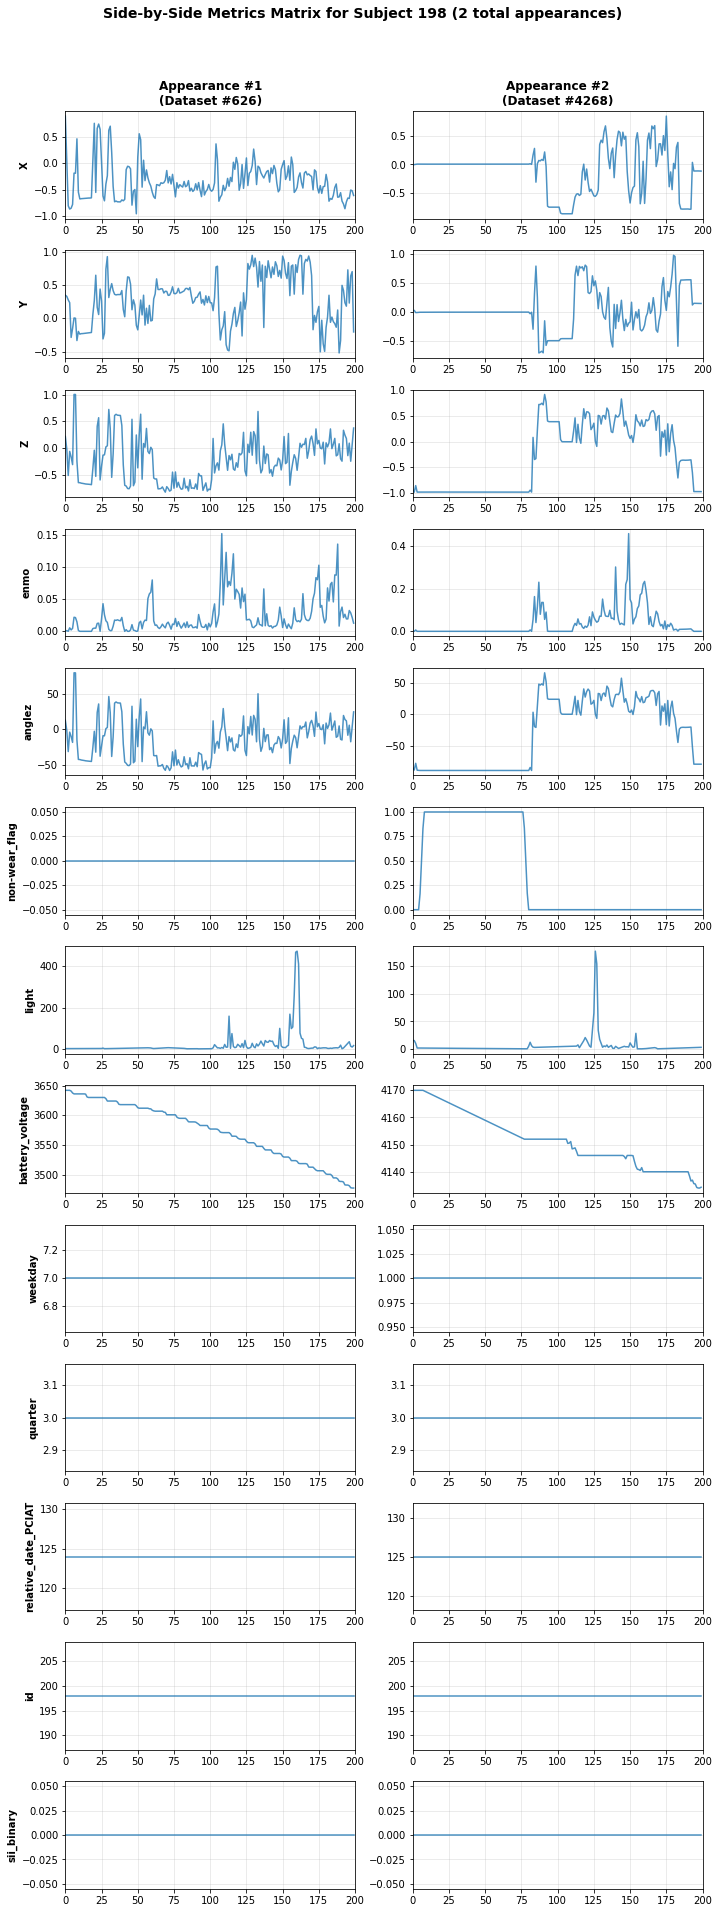

In [150]:
plot_subject_dashboard(CMI_timeseries_filtered, target_id="198", dataset_idx=None)

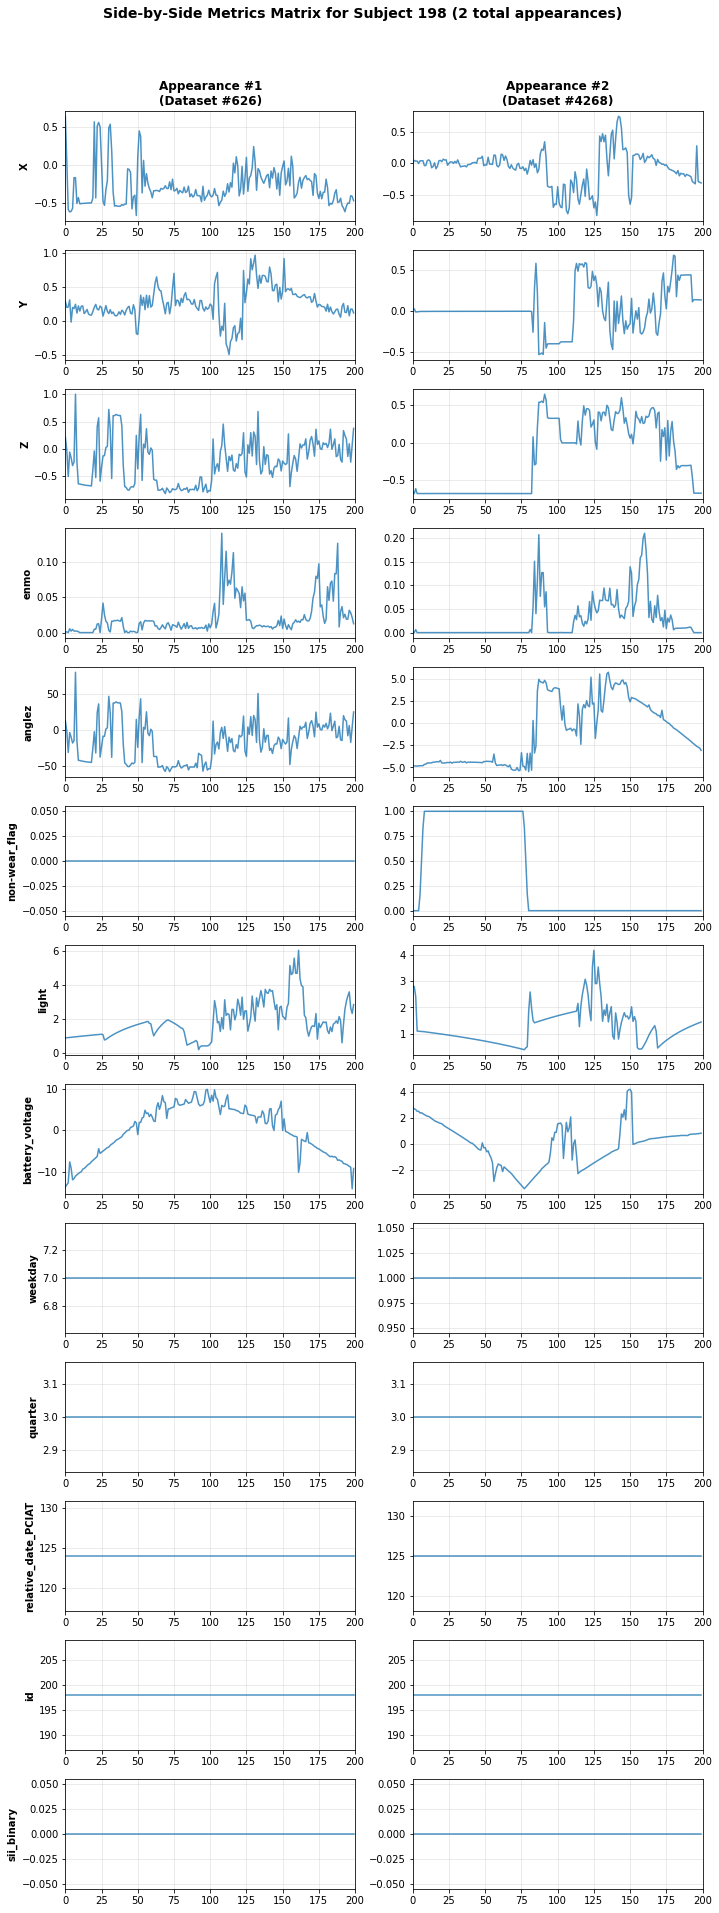

In [151]:
plot_subject_dashboard(CMI_timeseries_personalized, target_id="198", dataset_idx=None)

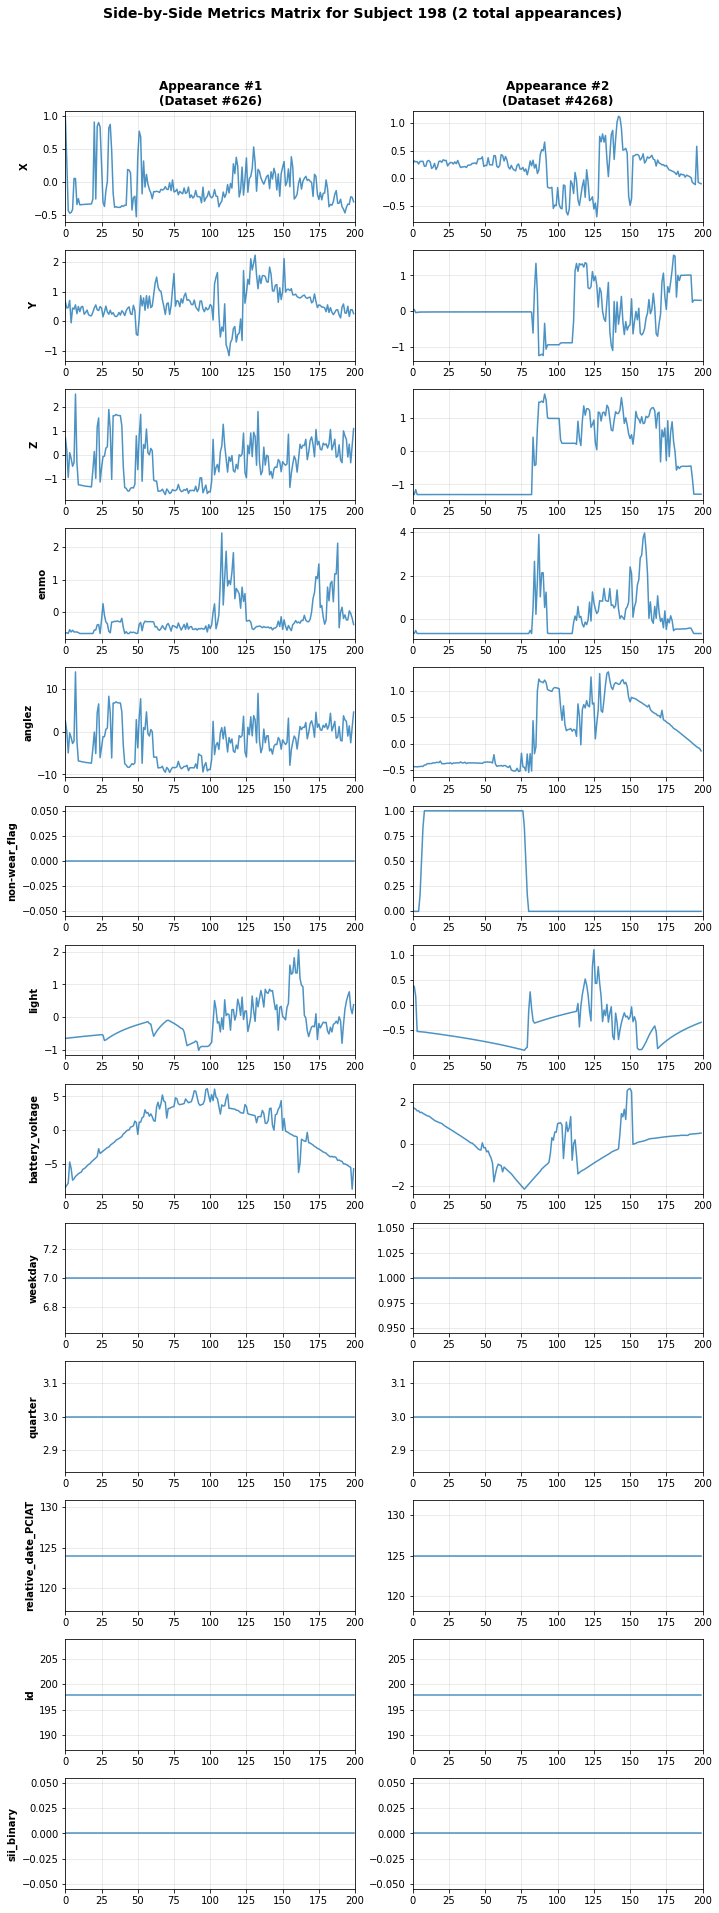

In [152]:
plot_subject_dashboard(CMI_timeseries_scaled, target_id="198", dataset_idx=None)

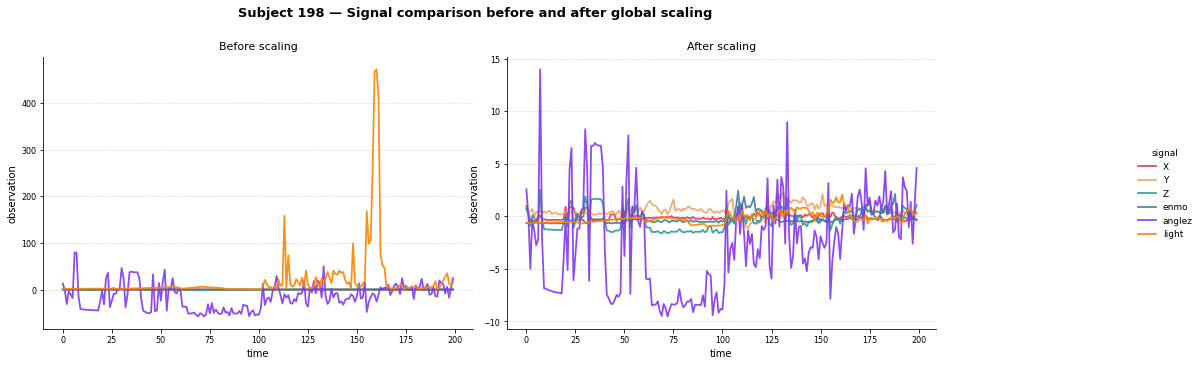

Plot saved to signal_before_after_scaling.png


In [153]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── CONFIG ────────────────────────────────────────────────────────────────────
TARGET_ID = 198
SIGNALS   = ["X", "Y", "Z", "enmo", "anglez", "light"]

# Color palette — one per signal
COLORS = {
    "X":      "#e63946",
    "Y":      "#f4a261",
    "Z":      "#2a9d8f",
    "enmo":   "#457b9d",
    "anglez": "#8338ec",
    "light":  "#fb8500",
}

# ── FETCH SUBJECT DATA ────────────────────────────────────────────────────────
def get_subject(df_list, target_id):
    for df in df_list:
        if df["id"].iloc[0] == target_id:
            return df
    return None

df_before = get_subject(CMI_timeseries_filtered, TARGET_ID)
df_after  = get_subject(CMI_timeseries_scaled,   TARGET_ID)

if df_before is None or df_after is None:
    raise ValueError(f"Subject {TARGET_ID} not found in one of the datasets.")

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 5))
fig.suptitle(
    f"Subject {TARGET_ID} — Signal comparison before and after global scaling",
    fontsize=13, fontweight="bold", y=1.02
)

gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.08)
ax_before = fig.add_subplot(gs[0])
ax_after  = fig.add_subplot(gs[1])

for signal in SIGNALS:
    if signal not in df_before.columns:
        continue
    color = COLORS[signal]
    t = np.arange(len(df_before))

    ax_before.plot(t, df_before[signal].values, label=signal,
                   color=color, linewidth=1.8, alpha=0.9)
    ax_after.plot(t,  df_after[signal].values,  label=signal,
                  color=color, linewidth=1.8, alpha=0.9)

# ── STYLING ───────────────────────────────────────────────────────────────────
for ax, title in [(ax_before, "Before scaling"), (ax_after, "After scaling")]:
    ax.set_xlabel("time", fontsize=10)
    ax.set_title(title, fontsize=11, pad=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

ax_before.set_ylabel("observation", fontsize=10)
ax_after.set_ylabel("observation", fontsize=10)

# Single shared legend on the right
handles, labels = ax_after.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="center right",
    bbox_to_anchor=(1.13, 0.5),
    frameon=False,
    fontsize=9,
    title="signal",
    title_fontsize=9,
)

plt.tight_layout()
#plt.savefig("signal_before_after_scaling.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to signal_before_after_scaling.png")